# Static Bethe-Salpeter for a fixed angle

This notebook computes the retarded excitonic propagator

$$D^R_{\mu\nu}(\Omega;\theta)=\left[V^{-1}\delta_{\mu\nu}-\Pi^R_{\mu\nu}(\Omega;\theta)\right]^{-1},$$

for two electronic layers coupled to classical magnetizations $\mathbf M_1$ and $\mathbf M_2$ with a fixed relative angle $\theta$.

The important point is that we follow the structure of the document: we start from the contour bubble, take its retarded component with Langreth rules, and only then transform to frequency.


## Spaces: layer, spin, and excitonic vertex

The full microscopic basis is

$$\Psi=(c^1_\uparrow,c^1_\downarrow,c^2_\uparrow,c^2_\downarrow)^T,$$

which lives in

$$\mathcal H_{\rm layer}\otimes\mathcal H_{\rm spin}.$$

The Pauli matrices $\sigma^a_{\rm spin}$ in the $s$-$d$ coupling act on the **physical spin inside each layer**:

$$h_l(k)=\epsilon_l(k)\sigma^0_{\rm spin}-J_{sd}\,\mathbf M_l\cdot\boldsymbol\sigma_{\rm spin}.$$

By contrast, the excitonic field

$$B^{\sigma\sigma'}=c^{1\dagger}_\sigma c^2_{\sigma'}$$

is an inter-layer bilinear. Its channel decomposition

$$B^\mu={\rm Tr}_{\rm spin}[\Gamma^\mu B],\qquad \Gamma^\mu=\sigma^\mu_{\rm spin}/\sqrt{2}$$

uses $\Gamma^\mu$ as a **vertex in the spin space of the electron-hole pair**. The layer structure is carried by the fact that the vertex connects $2\to1$; in this notebook we work blockwise, with $G_1$ and $G_2$ as the $2\times2$ spin Green functions of each layer.


## Retarded component

Applying Langreth rules and using time-translation invariance in equilibrium gives

$$\Pi^R_{\mu\nu}(\Omega)=-\frac{i}{L}\sum_k\int\frac{d\omega}{2\pi}{\rm Tr}_{\rm spin}\left[\Gamma_\mu^\dagger G^{1,R}_M(k,\omega+\Omega)\Gamma_\nu G^{2,<}_M(k,\omega)+\Gamma_\mu^\dagger G^{1,<}_M(k,\omega+\Omega)\Gamma_\nu G^{2,A}_M(k,\omega)\right].$$

This is the direct retarded version of the contour expression in the document. The band formula used below is the equilibrium Lehmann benchmark of the same object.


In [110]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10)


In [385]:
# -----------------------------
# Physical and numerical parameters
# Defaults are for notebook/smoke tests. Increase L, NΩ, and Nω for production runs.
# -----------------------------
L = 100#36                        # momentum points; increase for production
γ = 1.0                       # intralayer hopping
Δ_layer = 8.0                 # energy offset between layers: ε1=+Δ/2+εk, ε2=-Δ/2+εk
Jsd = -1.0#0.1                    # s-d coupling
Mmag = 1.0                    # magnitude of the classical magnetizations
θ = π/4                   # fixed angle between M1 and M2
V = -1.2                      # effective excitonic attraction in D=(V^{-1}-Π)^{-1}
T = 0.08                      # electronic temperature
μchem = 0.0                   # common chemical potential
μbias = 0.5                   # chemical imbalance between layers: μ1-μ2
μ1 = μchem + μbias/2          # chemical potential of layer 1/conduction
μ2 = μchem - μbias/2          # chemical potential of layer 2/valence
ηe = 0.08                     # electronic Green-function broadening
ηΩ = 2ηe                      # effective broadening of the band benchmark

Ωmin, Ωmax, NΩ = -10.0, 25.0, 401#121 -20.0 -10.0, 15.0, 401
ωmin, ωmax, Nω = -25.0, 25.0, 601#601#401 -15.0, 15.0, 601
ks = collect(range(-π, stop=π - 2π/L, length=L))
Ωs = collect(range(Ωmin, Ωmax, length=NΩ))
ωs = collect(range(ωmin, ωmax, length=Nω))
dω = ωs[2] - ωs[1];


In [386]:
# Pauli matrices in physical spin space.
σ_spin_0 = ComplexF64[1 0; 0 1]
σ_spin_x = ComplexF64[0 1; 1 0]
σ_spin_y = ComplexF64[0 -1im; 1im 0]
σ_spin_z = ComplexF64[1 0; 0 -1]
σ_spin = [σ_spin_0, σ_spin_x, σ_spin_y, σ_spin_z]

# Excitonic vertices. They are 2x2 matrices between the spin copies of layer 2 and layer 1.
# The inter-layer structure is not in Γ; it is in the bilinear c1† Γ c2.
Γ_exciton = σ_spin ./ sqrt(2)
channel_labels = ["0", "x", "y", "z"];


In [387]:
ϵk(k; γ=γ) = -2γ*cos(k)

function fermi(E; T=T, μ=0.0)
    x = (E - μ) / T
    x > 60 && return 0.0
    x < -60 && return 1.0
    return 1 / (exp(x) + 1)
end

function layer_chemical_potential(layer::Int)
    return layer == 1 ? μ1 : μ2
end

function h_layer(k, M; layer::Int)
    offset = layer == 1 ? +Δ_layer/2 : Δ_layer/2
    energy = (ϵk(k) + offset) * σ_spin_0 - Jsd * (M[1]*σ_spin_x + M[2]*σ_spin_y + M[3]*σ_spin_z)
    energy .*= (-1)^(layer+1)
    energy .-= layer_chemical_potential(layer) * σ_spin_0
    energy .+=10.0* σ_spin_z .+  10*σ_spin_0
    
    return energy
end

function magnetizations(θ)
    M1 = Mmag .* [0.0, 0.0, 1.0]
    M2 = Mmag .* [sin(θ), 0.0, cos(θ)]
    return M1, M2
end

function diagonalize_layers(ks, θ)
    M1, M2 = magnetizations(θ)

    E1 = zeros(Float64, 2, length(ks))
    E2 = zeros(Float64, 2, length(ks))
    U1 = Vector{Matrix{ComplexF64}}(undef, length(ks))
    U2 = Vector{Matrix{ComplexF64}}(undef, length(ks))

    for (ik, k) in enumerate(ks)
        F1 = eigen(Hermitian(h_layer(k, M1; layer=1)))
        F2 = eigen(Hermitian(h_layer(k, M2; layer=2)))
        E1[:, ik] .= F1.values
        E2[:, ik] .= F2.values
        U1[ik] = Matrix{ComplexF64}(F1.vectors)
        U2[ik] = Matrix{ComplexF64}(F2.vectors)
    end

    return (; M1, M2, E1, E2, U1, U2)
end

function green_R(h, ω; η=ηe)
    return inv((ω + 1im*η) * σ_spin_0 - h)
end

green_A(h, ω; η=ηe) = green_R(h, ω; η=η)'

green_less(h, ω; η=ηe) = fermi(ω) * (green_A(h, ω; η=η) - green_R(h, ω; η=η));


ComplexF64[0.0 + 0.0im 1.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im]
ComplexF64[0.0 + 0.0im 1.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im]


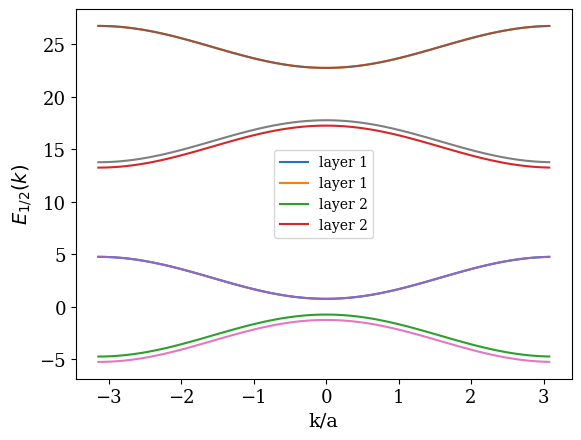

In [415]:
#ks = -pi:0.1:pi
e1(k,l) = eigen(h_layer(k, [0.,0.,1.0]; layer=l)).values
e2(k,l) = eigen(h_layer(k, [0.0,0.0,1.0]; layer=l)).values
# #eigen(h_layer(k, [0.,0.,1.0]; layer=1))
plt.ylabel(L"E_{1/2}(k)")
plt.xlabel("k/a")
plt.plot(ks,e1.(ks,1),label="layer 1")
plt.plot(ks,e2.(ks,2),label="layer 2")


e3(k,l) = eigen(h_layer(k, [0.,0.,1.0]; layer=l)).values
e4(k,l) = eigen(h_layer(k, [0.0,0.5,0.5]; layer=l)).values
plt.plot(ks,e3.(ks,1),)
plt.plot(ks,e4.(ks,2),)

#plt.ylim(-10,10)
plt.legend()
#(E1,E2, )=diagonalize_layers(ks, 0.0)
println(eigen(h_layer(0.0, [0.,0.,1.0]; layer=1)).vectors)
println(eigen(h_layer(0.0, [0.,0.,1.0]; layer=2)).vectors)

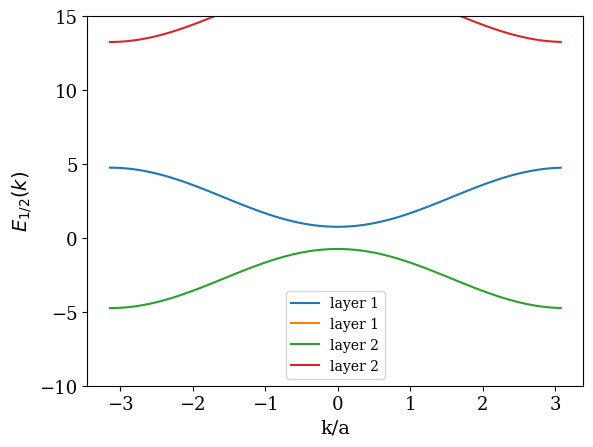

PyObject <matplotlib.legend.Legend object at 0x7f26f25519a0>

In [393]:
#ks = -pi:0.1:pi
e1(k) = eigen(h_layer(k, [0.,0.,1.0]; layer=1)).values
e2(k) = eigen(h_layer(k, [0.0,0.0,1.0]; layer=2)).values
# #eigen(h_layer(k, [0.,0.,1.0]; layer=1))
plt.ylabel(L"E_{1/2}(k)")
plt.xlabel("k/a")
plt.plot(ks,e1.(ks),label="layer 1")
plt.plot(ks,e2.(ks),label="layer 2")
plt.ylim(-10,15)
plt.legend()

In [394]:
function polarization_R_langreth(Ωs, ωs, ks, θ)
    M1, M2 = magnetizations(θ)
    Π = zeros(ComplexF64, 4, 4, length(Ωs))

    for k in ks
        h1 = h_layer(k, M1; layer=1)
        h2 = h_layer(k, M2; layer=2)

        for (iΩ, Ω) in enumerate(Ωs)
            acc = zeros(ComplexF64, 4, 4)
            for ω in ωs
                G1R = green_R(h1, ω + Ω)
                G1L = green_less(h1, ω + Ω)
                G2A = green_A(h2, ω)
                G2L = green_less(h2, ω)

                for μ in 4a1:4, ν in 1:4
                    Γμ = Γ_exciton[μ]
                    Γν = Γ_exciton[ν]
                    acc[μ, ν] += tr(Γμ' * G1R * Γν * G2L + Γμ' * G1L * Γν * G2A)
                end
            end
            Π[:, :, iΩ] .+= (-1im) * acc * dω / (2π * length(ks))
        end
    end

    return Π
end

function polarization_R_band_benchmark(Ωs, ks, θ)
    data = diagonalize_layers(ks, θ)
    Π = zeros(ComplexF64, 4, 4, length(Ωs))

    for (ik, _) in enumerate(ks)
        U1k = data.U1[ik]
        U2k = data.U2[ik]
        Mμ = [U1k' * Γ_exciton[μ] * U2k for μ in 1:4]

        for a in 1:2, b in 1:2
            ΔE = data.E1[a, ik] - data.E2[b, ik]
            occ = fermi(data.E2[b, ik]) - fermi(data.E1[a, ik])

            for (iΩ, Ω) in enumerate(Ωs)
                denom = Ω + 1im*ηΩ - ΔE
                pref = occ / denom / length(ks)
                for μ in 1:4, ν in 1:4
                    Π[μ, ν, iΩ] += pref * Mμ[μ][a, b] * conj(Mμ[ν][a, b])
                end
            end
        end
    end

    return Π, data
end

function exciton_propagator(Π; V=V)
    D = similar(Π)
    VinvI = (1/V) * Matrix{ComplexF64}(I, 4, 4)
    for iΩ in axes(Π, 3)
        D[:, :, iΩ] .= inv(VinvI - Π[:, :, iΩ])
    end
    return D
end

function spectral_trace(D)
    return [-2 * imag(tr(D[:, :, iΩ])) for iΩ in axes(D, 3)]
end;


In [395]:
# println("Computing Pi^R with Langreth + frequency integral...")
# Π = polarization_R_langreth(Ωs, ωs, ks, θ)
# D = exciton_propagator(Π)
# AD = spectral_trace(D)

println("Calculando benchmark de bandas...")
Π_band, layer_data = polarization_R_band_benchmark(Ωs, ks, θ)
D_band = exciton_propagator(Π_band)
AD_band = spectral_trace(D_band)

println("M1 = ", layer_data.M1)
println("M2 = ", layer_data.M2)
println("theta/pi = ", θ/π)
println("cos(theta) = ", dot(layer_data.M1, layer_data.M2)/(norm(layer_data.M1)*norm(layer_data.M2)))


Calculando benchmark de bandas...
M1 = [0.0, 0.0, 1.0]
M2 = [0.7071067811865475, 0.0, 0.7071067811865476]
theta/pi = 0.25
cos(theta) = 0.7071067811865476


## Figure 1: bare electron-hole continuum

Before looking at the excitonic propagator, we plot the bare transition energies

$$\Delta E_{ab}(k)=E^1_a(k)-E^2_b(k).$$

The lower edge of this continuum is the reference for identifying bound excitonic modes.


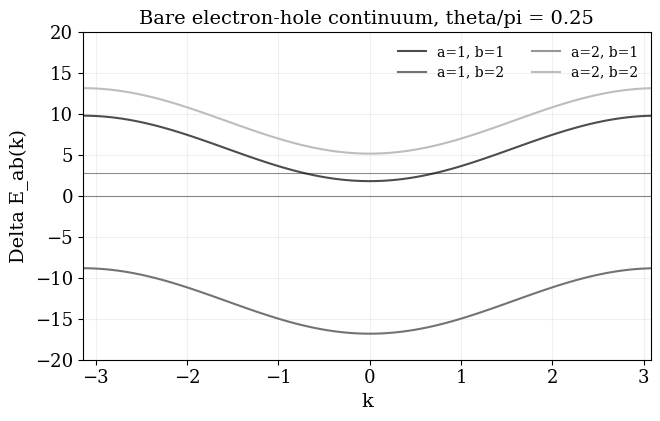

In [396]:
fig, ax = subplots(figsize=(6.8, 4.4))
colors = ["#4d4d4d", "#737373", "#969696", "#bdbdbd"]
idx = 1
for a in 1:2, b in 1:2
    ΔEab = layer_data.E1[a, :] .- layer_data.E2[b, :]
    ax.plot(ks, ΔEab; color=colors[idx], lw=1.5, label="a=$a, b=$b")
    idx += 1
end
ax.axhline(0, color="black", lw=0.8, alpha=0.45)

ax.axhline(2.8, color="black", lw=0.8, alpha=0.45)
ax.set_xlabel("k")
ax.set_ylabel("Delta E_ab(k)")
ax.set_title("Bare electron-hole continuum, theta/pi = $(round(θ/π; digits=3))")
ax.set_xlim(first(ks), last(ks))
ax.grid(alpha=0.18)

ax.legend(frameon=false, ncol=2)
plt.ylim(-20,20)
fig.tight_layout()


## Figure 2: bare response versus BSE excitonic response

First we compute the retarded bubble $\Pi^R$ and then the BSE/RPA propagator

$$D^R(\Omega)=\left[V^{-1}I-\Pi^R(\Omega)\right]^{-1}.$$

The bare spectrum $-2\,\mathrm{Im}\,\mathrm{Tr}\,\Pi^R$ shows the electron-hole continuum. The dressed spectrum $-2\,\mathrm{Im}\,\mathrm{Tr}\,D^R$ shows collective excitonic resonances. A peak in $D$ that is not present in $\Pi$ is the relevant excitonic signal.


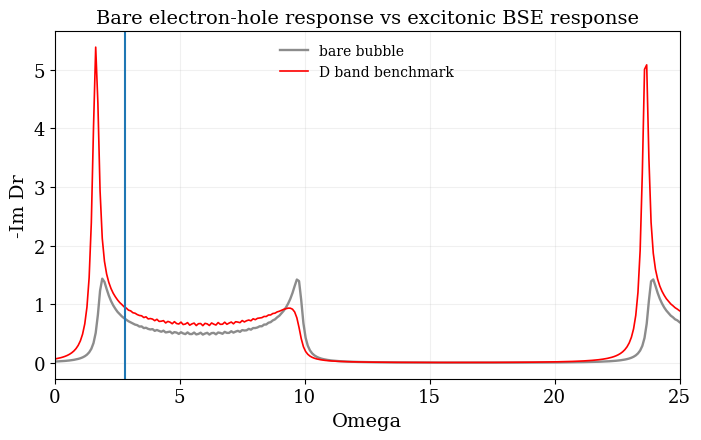

In [397]:
AΠ = [-2 * imag(tr(Π_band[:, :, iΩ])) for iΩ in axes(Π_band, 3)]
# detvals = [abs(det((1/V) * Matrix{ComplexF64}(I, 4, 4) - Π[:, :, iΩ])) for iΩ in axes(Π, 3)]
# i_peak = argmax(AD)
# i_det = argmin(detvals)

# Π and D do not have the same units/scale. Plot a rescaled bare response
# only as a shape/continuum reference on the same axis.
scale_AΠ = 1.0#maximum(abs.(AΠ)) > 0 ? maximum(abs.(AD)) / maximum(abs.(AΠ)) : 1.0
AΠ_scaled = scale_AΠ .* AΠ

fig, ax = subplots(figsize=(7.2, 4.6))
ax.plot(Ωs, AΠ_scaled; color="#8c8c8c", lw=1.7, alpha=1.0, label="bare bubble ")
# ax.plot(Ωs, AD; color="black", lw=2.3, label="BSE D from Langreth Pi")
ax.plot(Ωs, AD_band; color="red", lw=1.2, ls="-", alpha=1.0, label="D band benchmark")
#ax.axvline(Ωs[i_peak], color="black", lw=1.0, ls=":", label="D peak")
#ax.axvline(Ωs[i_det], color="#d95f0e", lw=1.0, ls="--", label="min det")
ax.set_xlabel("Omega")
ax.set_ylabel("-Im Dr")
ax.set_title("Bare electron-hole response vs excitonic BSE response")
ax.grid(alpha=0.18)
ax.legend(frameon=false)
ax.set_xlim(-0.0, 25)

ax.axvline(2.8)

fig.tight_layout()

# @printf("Langreth D peak: Omega = %+8.5f, weight = %+10.6f\n", Ωs[i_peak], AD[i_peak])
# @printf("min |det(V^{-1}I-Pi)|: Omega = %+8.5f, value = %.6e\n", Ωs[i_det], detvals[i_det])
# @printf("bare bubble scaling factor used in plot: %.6e\n", scale_AΠ)


## Figure 3: charge/spin channel content

Finally we separate the channels $\mu=0,x,y,z$ by plotting

$$-2\,\mathrm{Im}\,D^R_{\mu\mu}(\Omega).$$

This reveals whether the mode is mainly charge-like, longitudinal-spin-like, or transverse-spin-like in the fixed Cartesian basis.


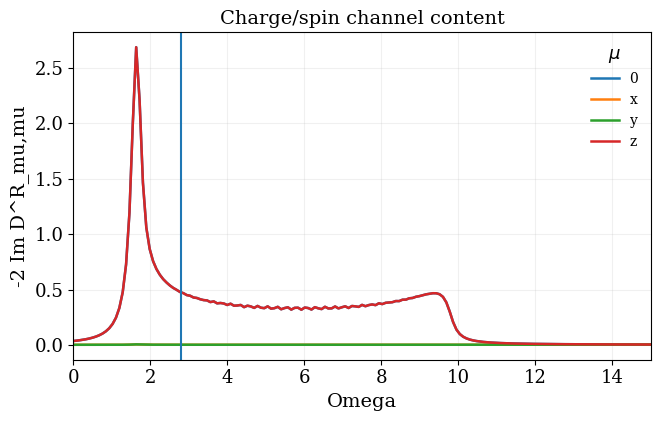

In [398]:
fig, ax = subplots(figsize=(6.8, 4.4))
for μ in 1:4
    Aμμ = [-2 * imag(D_band[μ, μ, iΩ]) for iΩ in axes(D_band, 3)]
    ax.plot(Ωs, Aμμ; lw=1.8, label=channel_labels[μ])
end
ax.set_xlabel("Omega")
ax.set_ylabel("-2 Im D^R_mu,mu")
ax.set_title("Charge/spin channel content")
ax.grid(alpha=0.18)
ax.legend(frameon=false, title=L"$\mu$")
ax.set_xlim(0, 15)
ax.axvline(2.8)




fig.tight_layout()


## Diagnostic: full channel tensor of $\mathrm{Im}\,D^R$

The previous plot keeps only the diagonal channel weights $D^R_{\mu\mu}$. To see channel mixing we also plot all entries

$$-2\,\mathrm{Im}\,D^R_{\mu\nu}(\Omega),\qquad \mu,\nu=0,x,y,z.$$

For $\mu\ne\nu$ this is a signed mixing diagnostic. It is not required to be positive; the positive spectral-weight statement applies directly to diagonal components, or to the full Hermitian spectral matrix.


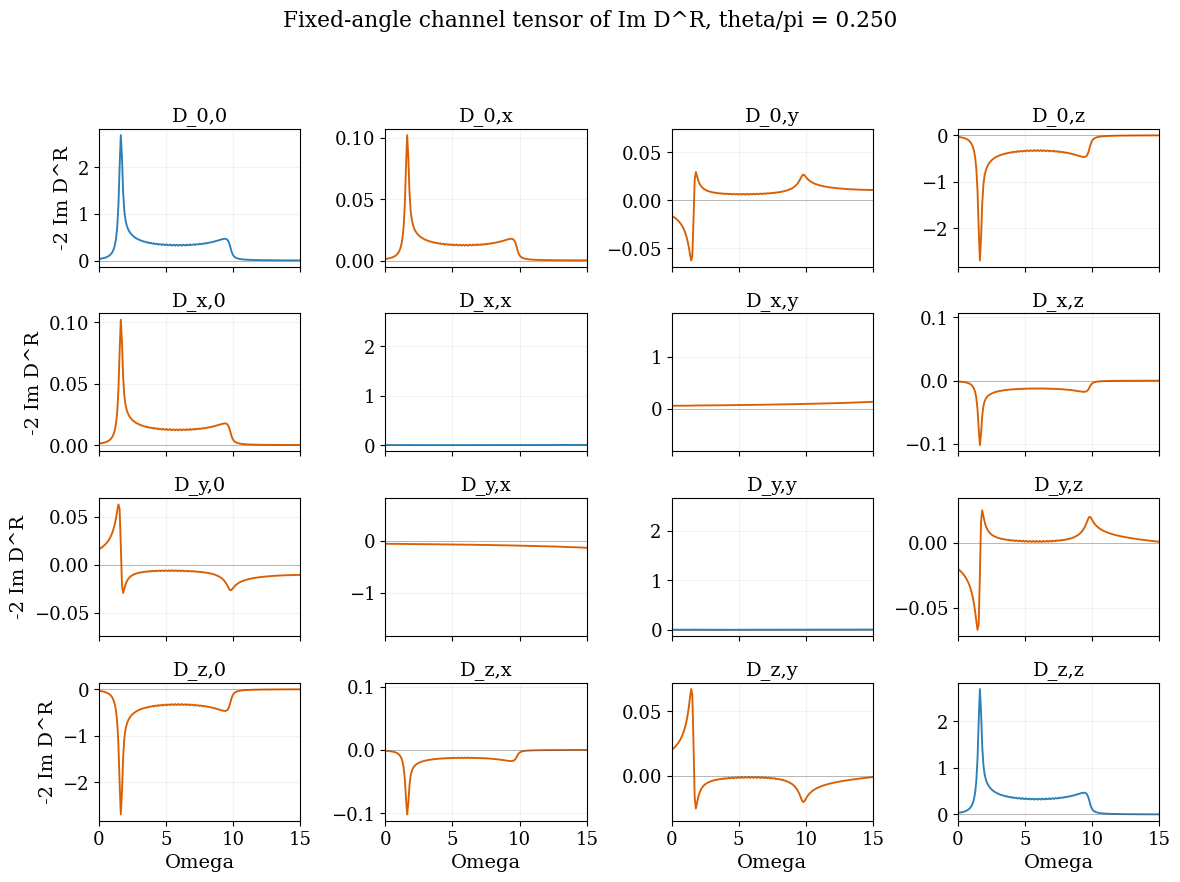

In [399]:
# -----------------------------
# Full fixed-angle channel tensor for Im D^R
# -----------------------------
Dmix_zero_tol = 1e-10              # components below this are shown as exact zero

function clean_component_line(y; tol=Dmix_zero_tol)
    out = collect(y)
    if maximum(abs.(out)) < tol
        out .= 0.0
    else
        out = [abs(v) < tol ? 0.0 : v for v in out]
    end
    return out
end

fig, axs = subplots(4, 4, figsize=(12.0, 9.0), sharex=true)
for μ in 1:4, ν in 1:4
    ax = axs[μ, ν]
    y = clean_component_line([-2 * imag(D_band[μ, ν, iΩ]) for iΩ in axes(D_band, 3)])
    ax.plot(Ωs, y, color=(μ == ν ? "#2c7fb8" : "#d95f02"), lw=1.35)
    ax.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax.set_title("D_" * channel_labels[μ] * "," * channel_labels[ν])
    ax.grid(alpha=0.16)
    ax.set_xlim(0, 15)
    if μ == 4
        ax.set_xlabel("Omega")
    end
    if ν == 1
        ax.set_ylabel("-2 Im D^R")
    end
end
fig.suptitle("Fixed-angle channel tensor of Im D^R, theta/pi = " * @sprintf("%.3f", θ/π))
fig.tight_layout(rect=(0, 0, 1, 0.94))


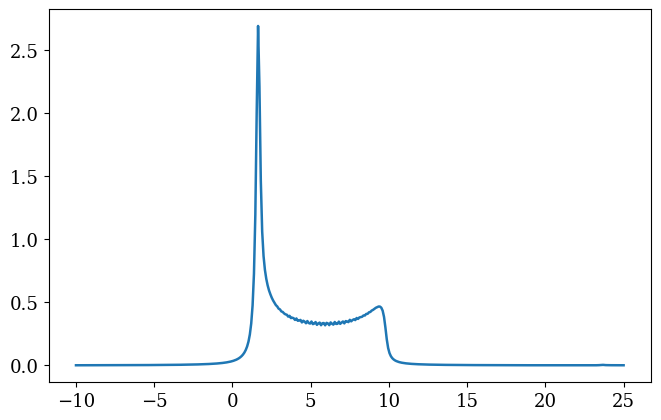

In [400]:
fig, ax = subplots(figsize=(6.8, 4.4))
Aμμ = [-2 * imag(D_band[4, 4, iΩ]) for iΩ in axes(D_band, 3)]
ax.plot(Ωs, Aμμ; lw=1.8, label="12")

fig.tight_layout()

## Additional diagnostic: channel mixing

As a quick numerical check, we compute

$$\max_\Omega |\Pi_{\mu\nu}(\Omega)|.$$

Large off-diagonal entries indicate that the fixed $0,x,y,z$ channel basis is not the eigenbasis of the excitonic response for the chosen magnetic configuration.


In [401]:
mixing = zeros(Float64, 4, 4)
for μ in 1:4, ν in 1:4
    mixing[μ, ν] = maximum(abs.(Π_band[μ, ν, :]))
end

println("max_Omega |Pi_{μν}(Omega;theta)|")
print("      ")
for label in channel_labels
    @printf("%12s", label)
end
println()
for μ in 1:4
    @printf("%4s  ", channel_labels[μ])
    for ν in 1:4
        @printf("%12.5e", mixing[μ, ν])
    end
    println()
end


max_Omega |Pi_{μν}(Omega;theta)|
                 0           x           y           z
   0   4.40838e-01 1.72863e-02 1.72932e-02 4.40798e-01
   x   1.72863e-02 4.34860e-01 4.34908e-01 1.72932e-02
   y   1.72932e-02 4.34908e-01 4.34860e-01 1.72863e-02
   z   4.40798e-01 1.72932e-02 1.72863e-02 4.40838e-01


## Fast angular sweep with the band formula

To sweep many angles we use the equilibrium band expression. It is much faster than the Langreth frequency integral and is the appropriate benchmark for this noninteracting equilibrium model:

$$\Pi^R_{\mu\nu}(\Omega;\theta)=\frac{1}{L}\sum_{k,a,b}\frac{f(E^2_{bk})-f(E^1_{ak})}{\Omega+i\eta-(E^1_{ak}-E^2_{bk})}M^\mu_{ab}(k)M^{\nu *}_{ab}(k).$$

For each $\theta$ we build $D^R(\Omega;\theta)$ and store

$$A_D(\Omega,\theta)=-2\,\mathrm{Im}\,\mathrm{Tr}\,D^R(\Omega;\theta).$$

This figure directly tests whether the problem is characterized by the relative angle between the magnetizations.


In [402]:
function continuum_edges(data)
    emin = Inf
    emax = -Inf
    for a in 1:2, b in 1:2
        ΔEab = data.E1[a, :] .- data.E2[b, :]
        emin = min(emin, minimum(ΔEab))
        emax = max(emax, maximum(ΔEab))
    end
    return emin, emax
end

function solve_angle_band(θval; Ωs=Ωs, ks=ks, V=V)
    Πθ, dataθ = polarization_R_band_benchmark(Ωs, ks, θval)
    Dθ = exciton_propagator(Πθ; V=V)
    ADθ = spectral_trace(Dθ)
    detθ = [abs(det((1/V) * Matrix{ComplexF64}(I, 4, 4) - Πθ[:, :, iΩ])) for iΩ in axes(Πθ, 3)]
    ipeak = argmax(ADθ)
    idet = argmin(detθ)
    cmin, cmax = continuum_edges(dataθ)
    return (; θ=θval, Π=Πθ, D=Dθ, AD=ADθ, detvals=detθ,
            Ωpeak=Ωs[ipeak], Apeak=ADθ[ipeak], Ωdet=Ωs[idet], detmin=detθ[idet],
            continuum_min=cmin, continuum_max=cmax, data=dataθ)
end;


In [403]:
Nθ = 25
θs = collect(range(0, π, length=Nθ))

println("Running band-method angle sweep with Nθ=$Nθ, NΩ=$(length(Ωs)), L=$(length(ks))")
sweep = [solve_angle_band(θval) for θval in θs]

AD_map = reduce(hcat, [s.AD for s in sweep])'          # size Nθ x NΩ
Ωpeaks = [s.Ωpeak for s in sweep]
Apeaks = [s.Apeak for s in sweep]
Ωdets = [s.Ωdet for s in sweep]
cont_min = [s.continuum_min for s in sweep]
cont_max = [s.continuum_max for s in sweep]

# @printf("θ/pi range: %.3f to %.3f\n", first(θs)/π, last(θs)/π)
# @printf("peak Ω range: %.5f to %.5f\n", minimum(Ωpeaks), maximum(Ωpeaks))
# @printf("continuum lower edge range: %.5f to %.5f\n", minimum(cont_min), maximum(cont_min))


Running band-method angle sweep with Nθ=25, NΩ=401, L=100


25-element Vector{Float64}:
 31.5
 31.50950069496217
 31.537780893240253
 31.584184572639103
 31.647649530032904
 31.726750955465054
 31.819756669370133
 31.92468946012682
 32.03939201416946
 32.16159051878614
 32.28895393277288
 32.41914694697074
 32.54987562112089
 32.678925475923336
 32.80419239446015
 32.92370704918849
 33.03565375285274
 33.13838467908425
 33.23043035594244
 33.31050724091264
 33.37752306711821
 33.43058052667953
 33.46897973951002
 33.492219849851814
 33.5

## Figure 4: spectral map $A_D(\Omega,\theta)$

The intensity shows the BSE excitonic spectrum as a function of frequency and relative spin angle. The overlaid lines show the main spectral peak, the minimum of the BSE determinant, and the lower/upper edges of the bare electron-hole continuum.


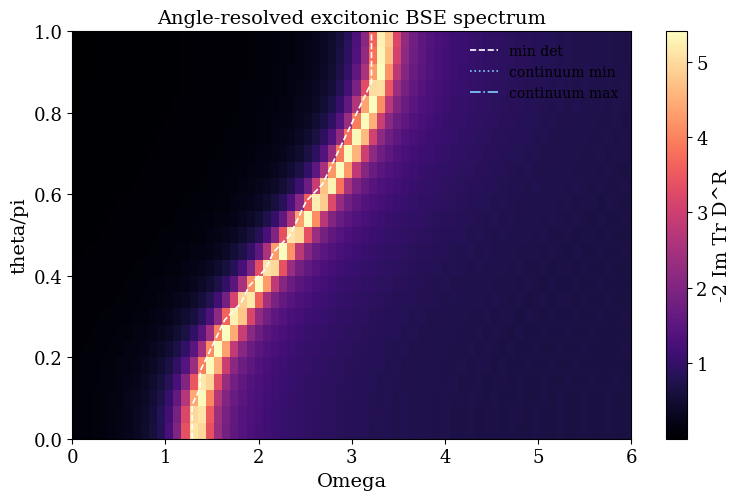

In [408]:
fig, ax = subplots(figsize=(8.0, 5.2))
θ_over_pi = θs ./ π
img = ax.imshow(AD_map; origin="lower", aspect="auto",
               extent=(first(Ωs), last(Ωs), first(θ_over_pi), last(θ_over_pi)),
               cmap="magma")
#ax.plot(Ωpeaks, θ_over_pi; color="cyan", lw=1.6, label="AD peak")
ax.plot(Ωdets, θ_over_pi; color="white", lw=1.2, ls="--", label="min det")
ax.plot(cont_min, θ_over_pi; color="#7dd3fc", lw=1.2, ls=":", label="continuum min")
ax.plot(cont_max, θ_over_pi; color="#7dd3fc", lw=1.2, ls="-.", label="continuum max")
ax.set_xlabel("Omega")
ax.set_ylabel("theta/pi")
ax.set_title("Angle-resolved excitonic BSE spectrum")
ax.set_xlim(0.0, 6)
ax.legend(frameon=false, loc="upper right")
fig.colorbar(img, ax=ax, label="-2 Im Tr D^R")
fig.tight_layout()


## Figure 5: channel-resolved spectral maps

The total trace can be nearly independent of $\theta$ because the problem is rotationally invariant when $V$ is proportional to the identity in channel space. To see whether the angle redistributes spectral weight among channels, we plot separately

$$A_\mu(\Omega,\theta)=-2\,\mathrm{Im}\,D^R_{\mu\mu}(\Omega;\theta),\qquad \mu=0,x,y,z.$$

These maps do not recompute the bubble: they use the propagators stored in `sweep`.


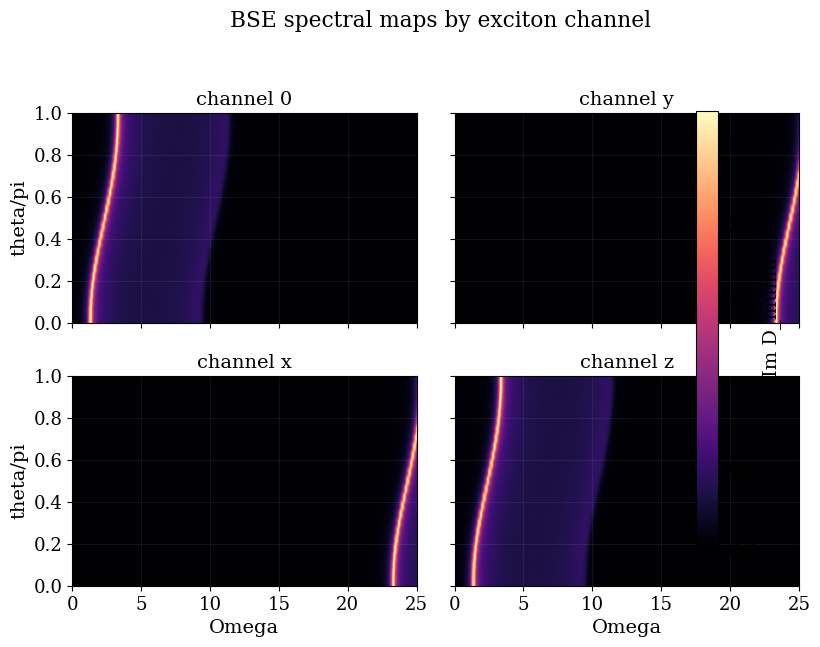

In [409]:
component_maps = [reduce(hcat, [[-2 * imag(s.D[μ, μ, iΩ]) for iΩ in axes(s.D, 3)] for s in sweep])' for μ in 1:4]

fig, axs = subplots(2, 2, figsize=(9.0, 6.6), sharex=true, sharey=true)
axs_flat = vec(axs)
θ_over_pi = θs ./ π
vmax_comp = maximum(abs.(vcat([vec(Aμ) for Aμ in component_maps]...)))
vmax_comp = vmax_comp > 0 ? vmax_comp : 1.0

for μ in 1:4
    ax = axs_flat[μ]
    img = ax.imshow(component_maps[μ]; origin="lower", aspect="auto",
                   extent=(first(Ωs), last(Ωs), first(θ_over_pi), last(θ_over_pi)),
                   cmap="magma", vmin=0, vmax=vmax_comp)
    ax.plot(cont_min, θ_over_pi; color="#7dd3fc", lw=1.0, ls=":")
    ax.plot(cont_max, θ_over_pi; color="#7dd3fc", lw=1.0, ls="-.")
    ax.set_xlim(0, 25)
    ax.set_title("channel " * channel_labels[μ])
    ax.grid(alpha=0.10)
end

axs[2, 1].set_xlabel("Omega")
axs[2, 2].set_xlabel("Omega")
axs[1, 1].set_ylabel("theta/pi")
axs[2, 1].set_ylabel("theta/pi")
fig.colorbar(img, ax=axs_flat, shrink=0.86, label="-2 Im D_mumu")
fig.suptitle("BSE spectral maps by exciton channel")
fig.tight_layout(rect=(0, 0, 0.92, 0.95))


## Diagnostic: angle-resolved mixed channel maps

Using the same `sweep` as Figure 5, this figure shows the full channel tensor $-2\,\mathrm{Im}\,D^R_{\mu\nu}(\Omega;\theta)$. The off-diagonal panels reveal whether changing the magnetic angle only rotates spectral weight among channels or also creates finite mixed components in the fixed Cartesian basis.


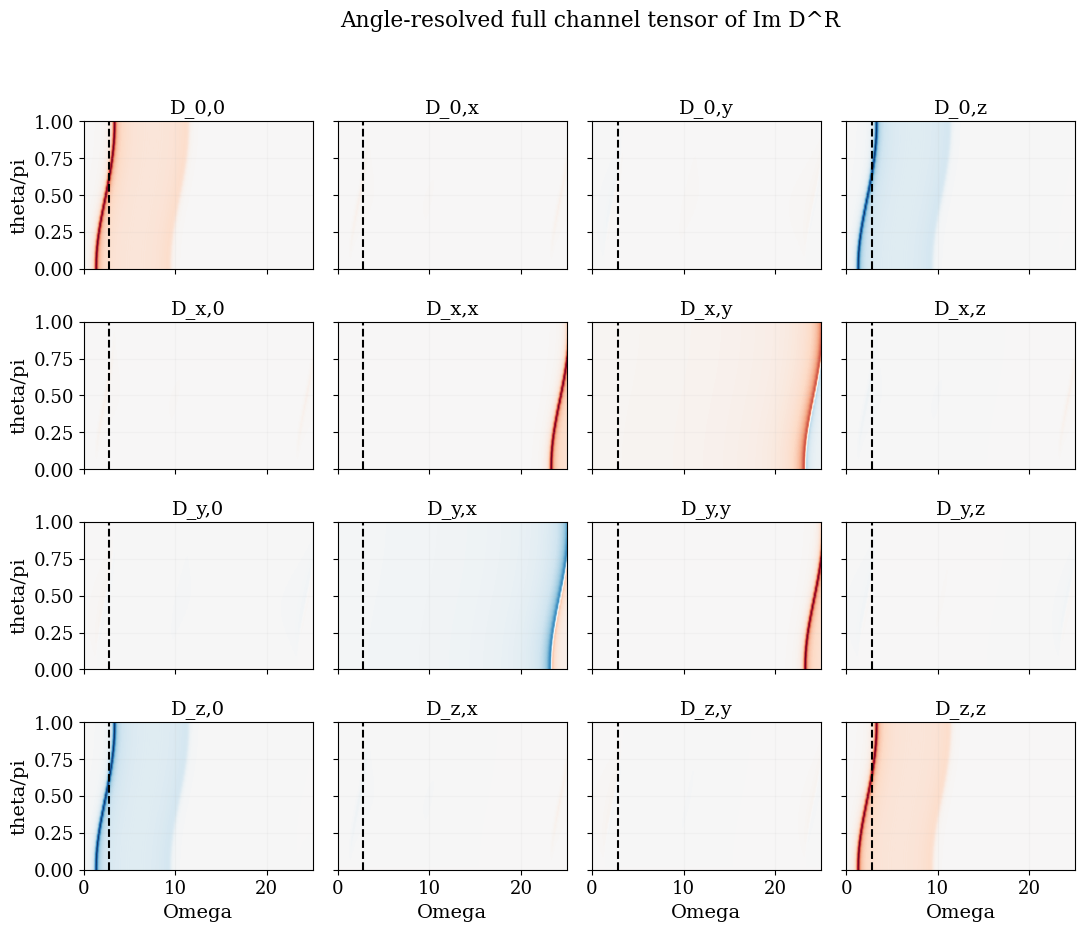

In [413]:
# -----------------------------
# Angle-resolved full channel tensor for Im D^R
# -----------------------------
if !(@isdefined(Dmix_zero_tol))
    Dmix_zero_tol = 1e-10
end

function clean_component_map(A; tol=Dmix_zero_tol)
    out = copy(A)
    if maximum(abs.(out)) < tol
        out .= 0.0
    else
        out[abs.(out) .< tol] .= 0.0
    end
    return out
end

D_component_maps = Matrix{Array{Float64, 2}}(undef, 4, 4)
for μ in 1:4, ν in 1:4
    Aμν = permutedims(reduce(hcat, [[-2 * imag(s.D[μ, ν, iΩ]) for iΩ in axes(s.D, 3)] for s in sweep]))
    D_component_maps[μ, ν] = clean_component_map(Aμν)
end

all_D_components = vcat([vec(D_component_maps[μ, ν]) for μ in 1:4 for ν in 1:4]...)
vmax_Dmix = maximum(abs.(all_D_components))
vmax_Dmix = vmax_Dmix > 0 ? vmax_Dmix : 1.0

fig, axs = subplots(4, 4, figsize=(12.0, 9.5), sharex=true, sharey=true)
θ_over_pi = θs ./ π
for μ in 1:4, ν in 1:4
    ax = axs[μ, ν]
    img = ax.imshow(D_component_maps[μ, ν]; origin="lower", aspect="auto",
                    extent=(first(Ωs), last(Ωs), first(θ_over_pi), last(θ_over_pi)),
                    cmap="RdBu_r", vmin=-vmax_Dmix, vmax=vmax_Dmix)
    ax.plot(cont_min, θ_over_pi; color="0.15", lw=0.8, ls=":", alpha=0.8)
    ax.plot(cont_max, θ_over_pi; color="0.15", lw=0.8, ls="-.", alpha=0.8)
    ax.set_xlim(0, 25)
    ax.set_title("D_" * channel_labels[μ] * "," * channel_labels[ν])
    ax.grid(alpha=0.08)
    ax.axvline(2.8,color="black", ls = "--")
    if μ == 4
        ax.set_xlabel("Omega")
    end
    if ν == 1
        ax.set_ylabel("theta/pi")
    end
end
#fig.colorbar(img, ax=vec(axs), shrink=0.82, label="-2 Im D_munu")
fig.suptitle("Angle-resolved full channel tensor of Im D^R")
fig.tight_layout(rect=(0, 0, 0.92, 0.95))


## Figure 6: mode energy versus angle

This figure summarizes the previous map by reducing each spectrum to the main peak energy and the determinant minimum. It is useful for seeing whether the excitonic branch is primarily controlled by $\cos\theta$.


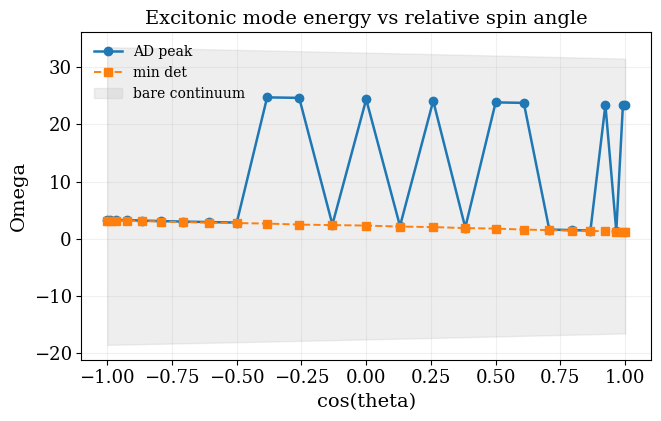

In [412]:
xcos = cos.(θs)
order = sortperm(xcos)

fig, ax = subplots(figsize=(6.8, 4.4))
ax.plot(xcos[order], Ωpeaks[order]; marker="o", lw=1.8, label="AD peak")
ax.plot(xcos[order], Ωdets[order]; marker="s", lw=1.4, ls="--", label="min det")
ax.fill_between(xcos[order], cont_min[order], cont_max[order]; color="#bdbdbd", alpha=0.25, label="bare continuum")
ax.set_xlabel("cos(theta)")
ax.set_ylabel("Omega")
ax.set_title("Excitonic mode energy vs relative spin angle")
ax.grid(alpha=0.18)
ax.legend(frameon=false)


#ax.set_ylim(3.0,3.5)
fig.tight_layout()


## What to look at next

The angular characterization is now contained in `solve_angle_band(θ)` and in the sweep over $\theta\in[0,\pi]`. The central object is the color map

$$A_D(\Omega,\theta)=-2\,\mathrm{Im}\,\mathrm{Tr}\,D^R(\Omega;\theta),$$

with horizontal axis `Ω` and vertical axis `θ` or `cos(θ)`.


## Figure 7: excitonic susceptibility in time

To visualize the time-domain response of each channel, we use an independent frequency grid for the Fourier transform and compute directly

$$D^R_{\mu\mu}(t;\theta)\simeq \int_{\Omega^{\rm FT}_{\min}}^{\Omega^{\rm FT}_{\max}}\frac{d\Omega}{2\pi}\,W(\Omega)\,e^{-i\Omega t}D^R_{\mu\mu}(\Omega;\theta).$$

$W(\Omega)$ is an optional numerical window used to smooth the finite frequency cutoff. Each panel shows $\mathrm{Re}\,D^R_{\mu\mu}(t;\theta)$ for one excitonic channel and compares $\theta=0,\pi/2,\pi$.

To reduce Fourier noise, use a symmetric frequency grid, many $\Omega$ points, and a moderate time range.


Fourier grid: Ω in [-15.0, 15.0], NΩ=2001, Hann window=true


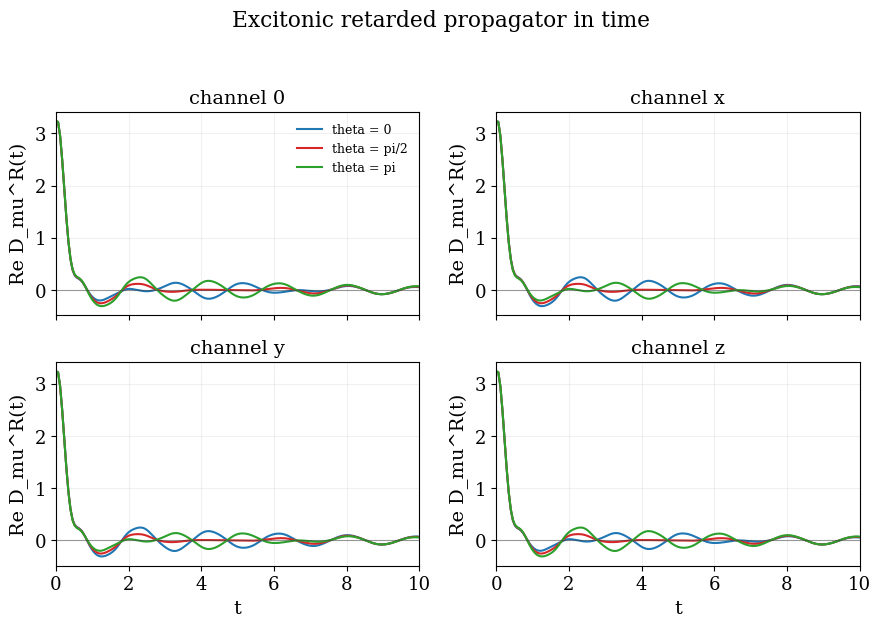

In [58]:
# Independent parameters for the time-domain Fourier transform.
Ωtime_min = -15.0
Ωtime_max = 15.0
NΩtime = 2001
Ωs_time = collect(range(Ωtime_min, Ωtime_max, length=NΩtime))

tmax_time = 40.0
Nt_time = 700
ts = collect(range(0.0, tmax_time, length=Nt_time))

use_hann_window = true

function hann_window(n::Int)
    n <= 1 && return ones(Float64, n)
    return [0.5 * (1 - cos(2π * (j - 1) / (n - 1))) for j in 1:n]
end

function inverse_fourier_retarded(DΩ, Ωs, ts; use_window=true)
    dΩ = length(Ωs) > 1 ? Ωs[2] - Ωs[1] : 1.0
    W = use_window ? hann_window(length(Ωs)) : ones(Float64, length(Ωs))
    return [sum((W .* DΩ) .* exp.(-1im .* Ωs .* t)) * dΩ / (2π) for t in ts]
end

function channel_time_response_band(θval, ts; Ωs_ft=Ωs_time, ks=ks, V=V, use_window=use_hann_window)
    sol = solve_angle_band(θval; Ωs=Ωs_ft, ks=ks, V=V)
    Dt = zeros(ComplexF64, 4, length(ts))
    for μ in 1:4
        DμΩ = [sol.D[μ, μ, iΩ] for iΩ in axes(sol.D, 3)]
        Dt[μ, :] .= inverse_fourier_retarded(DμΩ, Ωs_ft, ts; use_window=use_window)
    end
    return Dt
end

time_angles = [0.0, π/2, π]
time_angle_labels = ["0", "pi/2", "pi"]

println("Fourier grid: Ω in [$Ωtime_min, $Ωtime_max], NΩ=$NΩtime, Hann window=$use_hann_window")
Dtime_by_angle = [channel_time_response_band(θval, ts) for θval in time_angles]

fig, axs = subplots(2, 2, figsize=(9.0, 6.4), sharex=true)
axs_flat = [axs[1, 1], axs[1, 2], axs[2, 1], axs[2, 2]]
colors = ["#1f77b4", "#d62728", "#2ca02c"]

for μ in 1:4
    ax = axs_flat[μ]
    for ia in eachindex(time_angles)
        ax.plot(ts, -real.(Dtime_by_angle[ia][μ, :]), lw=1.5, color=colors[ia],
                label="theta = " * time_angle_labels[ia])
    end
    ax.axhline(0.0, color="0.25", lw=0.8, alpha=0.5)
    ax.set_title("channel " * channel_labels[μ])
    ax.set_ylabel("Re D_mu^R(t)")
    ax.grid(alpha=0.18)
    ax.set_xlim(0,10)
end

axs_flat[3].set_xlabel("t")
axs_flat[4].set_xlabel("t")
axs_flat[1].legend(frameon=false, fontsize=9)
fig.suptitle("Excitonic retarded propagator in time")
fig.tight_layout(rect=(0, 0, 1, 0.95))
